In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from stream_perturbing_halos import (
    find_mw_halos,
    fetch_subhalos,
    population_perturbation_rates,
    MW_HALO_MASS_MSUN,
    PERTURBER_R_RANGE_KPC,
)

params = {
    "text.usetex": True,
    "font.family": "serif",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.top": True,
    "ytick.left": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.size": 2.5,
    "xtick.major.size": 5,
    "ytick.minor.size": 2.5,
    "ytick.major.size": 5,
    "axes.axisbelow": False,
    "figure.dpi": 300,
}
plt.rcParams.update(params)

In [2]:
mw = find_mw_halos()
print(
    f"{len(mw)} MW analogs in M_central = "
    f"[{MW_HALO_MASS_MSUN[0]:.0e}, {MW_HALO_MASS_MSUN[1]:.0e}] Msun"
)
print(f"index range: {min(mw)}..{max(mw)}")

103 MW analogs in M_central = [1e+12, 2e+12] Msun
index range: 77..241


In [3]:
sh = {"id": [], "mass_msun": [], "R_kpc": [], "halo_pos_kpc": []}
for i in mw:
    subhalos = fetch_subhalos(i)
    for k in sh:
        sh[k].extend(subhalos[k])
for k in sh:
    sh[k] = np.array(sh[k])

print(f"\nN subhalos in [1e6, 1e9] Msun: {len(sh['id'])}")
print(f"M range: {sh['mass_msun'].min():.2e} to {sh['mass_msun'].max():.2e} Msun")
print(f"R range: {sh['R_kpc'].min():.2f} to {sh['R_kpc'].max():.2f} kpc")


N subhalos in [1e6, 1e9] Msun: 59675
M range: 1.64e+06 to 9.99e+08 Msun
R range: 1.76 to 51543.33 kpc


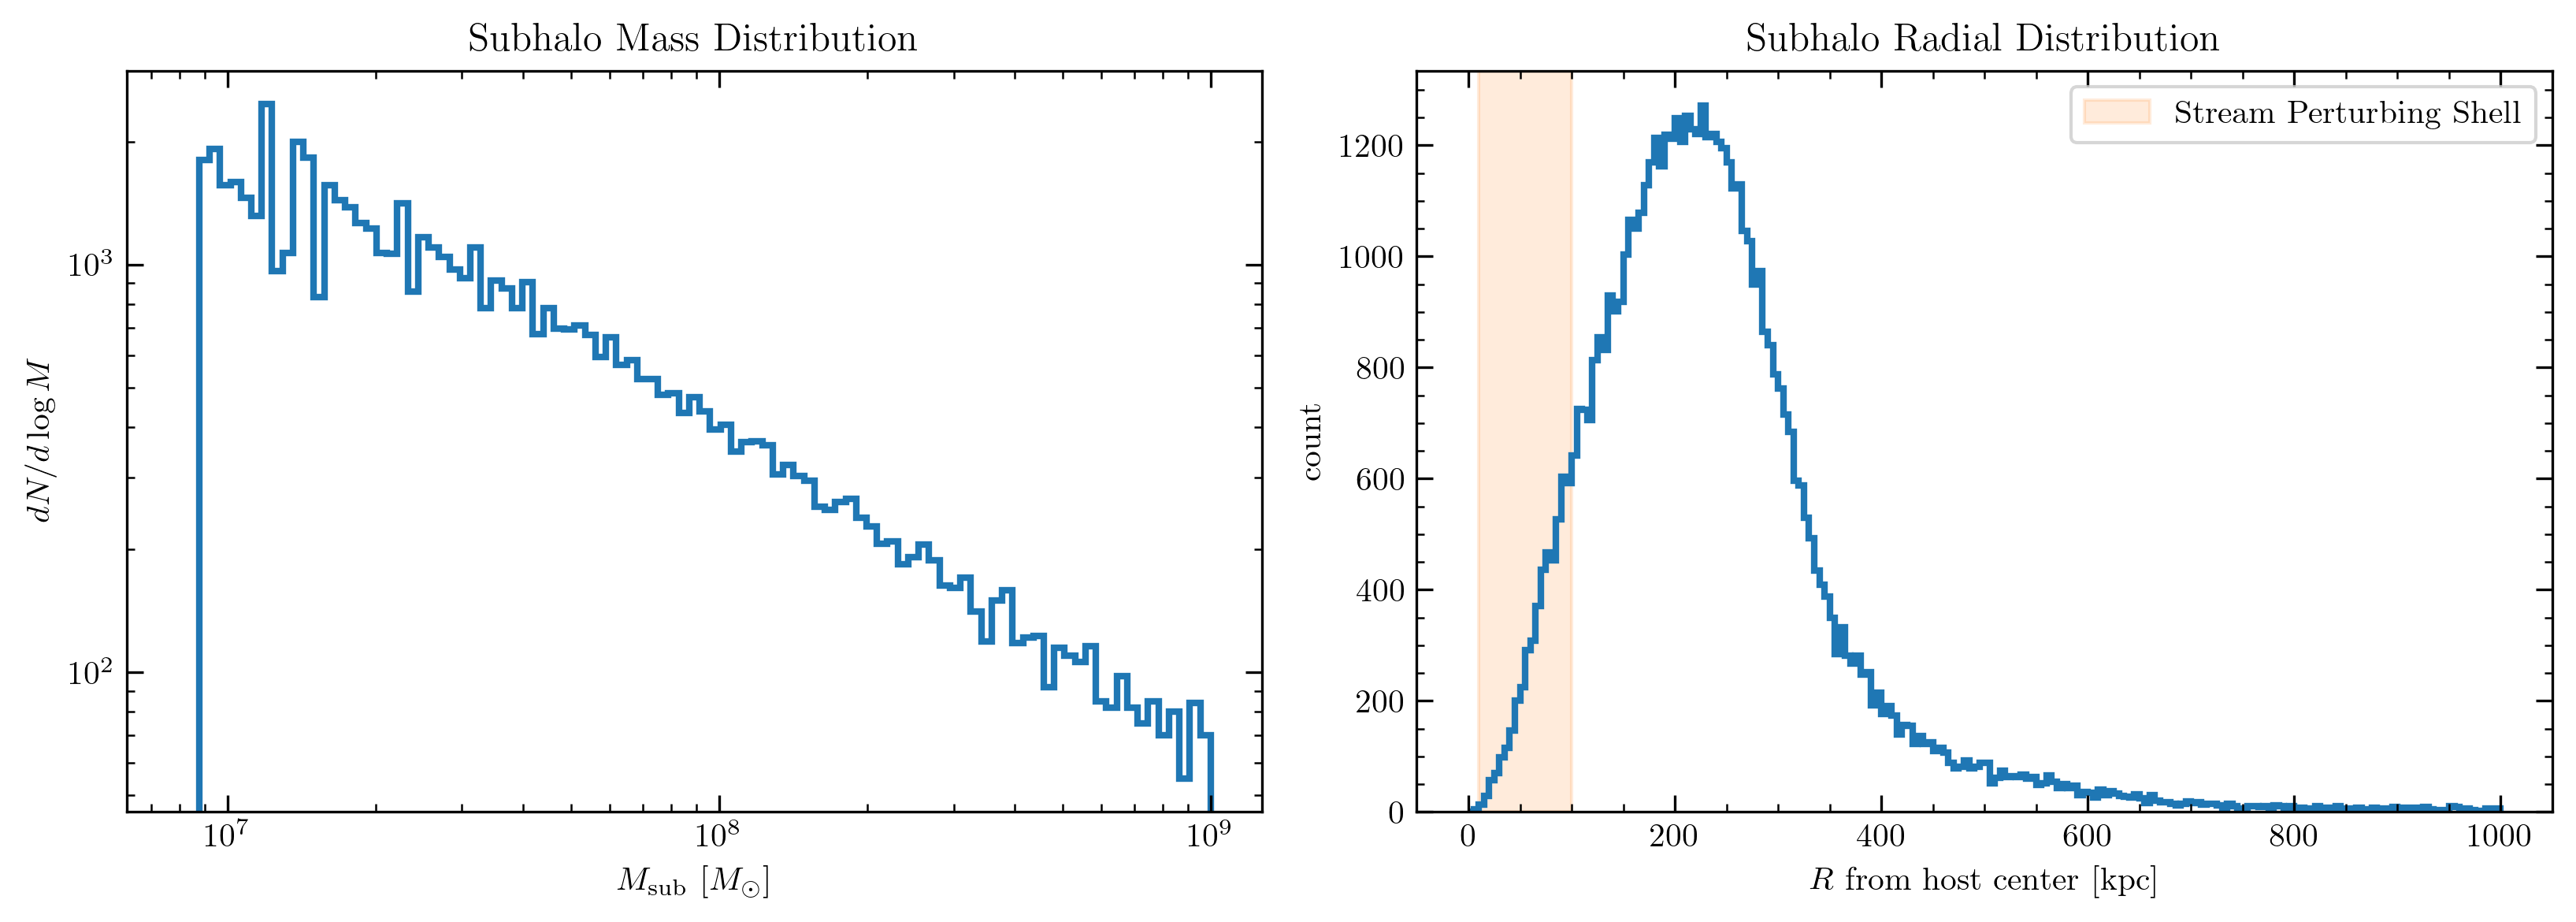

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Mass function
mbins = np.logspace(6.9, 9, 100)
axes[0].hist(sh["mass_msun"], bins=mbins, histtype="step", lw=2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$M_{\rm sub}\ [M_\odot]$")
axes[0].set_ylabel(r"$dN/d\log M$")
axes[0].set_title("Subhalo Mass Distribution")

# Radial distribution
axes[1].hist(sh["R_kpc"], bins=200, histtype="step", lw=2, range=[0, 1000])
axes[1].axvspan(
    *PERTURBER_R_RANGE_KPC, color="C1", alpha=0.15, label="Stream Perturbing Shell"
)
axes[1].set_xlabel(r"$R$ from host center [kpc]")
axes[1].set_ylabel("count")
axes[1].set_title("Subhalo Radial Distribution")
axes[1].legend()
fig.tight_layout()
fig.savefig("./plots/subhalo_mass_and_radial_distributions.png", dpi=300)

CDM N_perturb/kpc @ GD-1 (D=8 kpc, T=12 Gyr):
  median = 0.0488
  1-sigma range = 0.0309 – 0.0661
  full range across 103 hosts: 0.0222 – 0.11


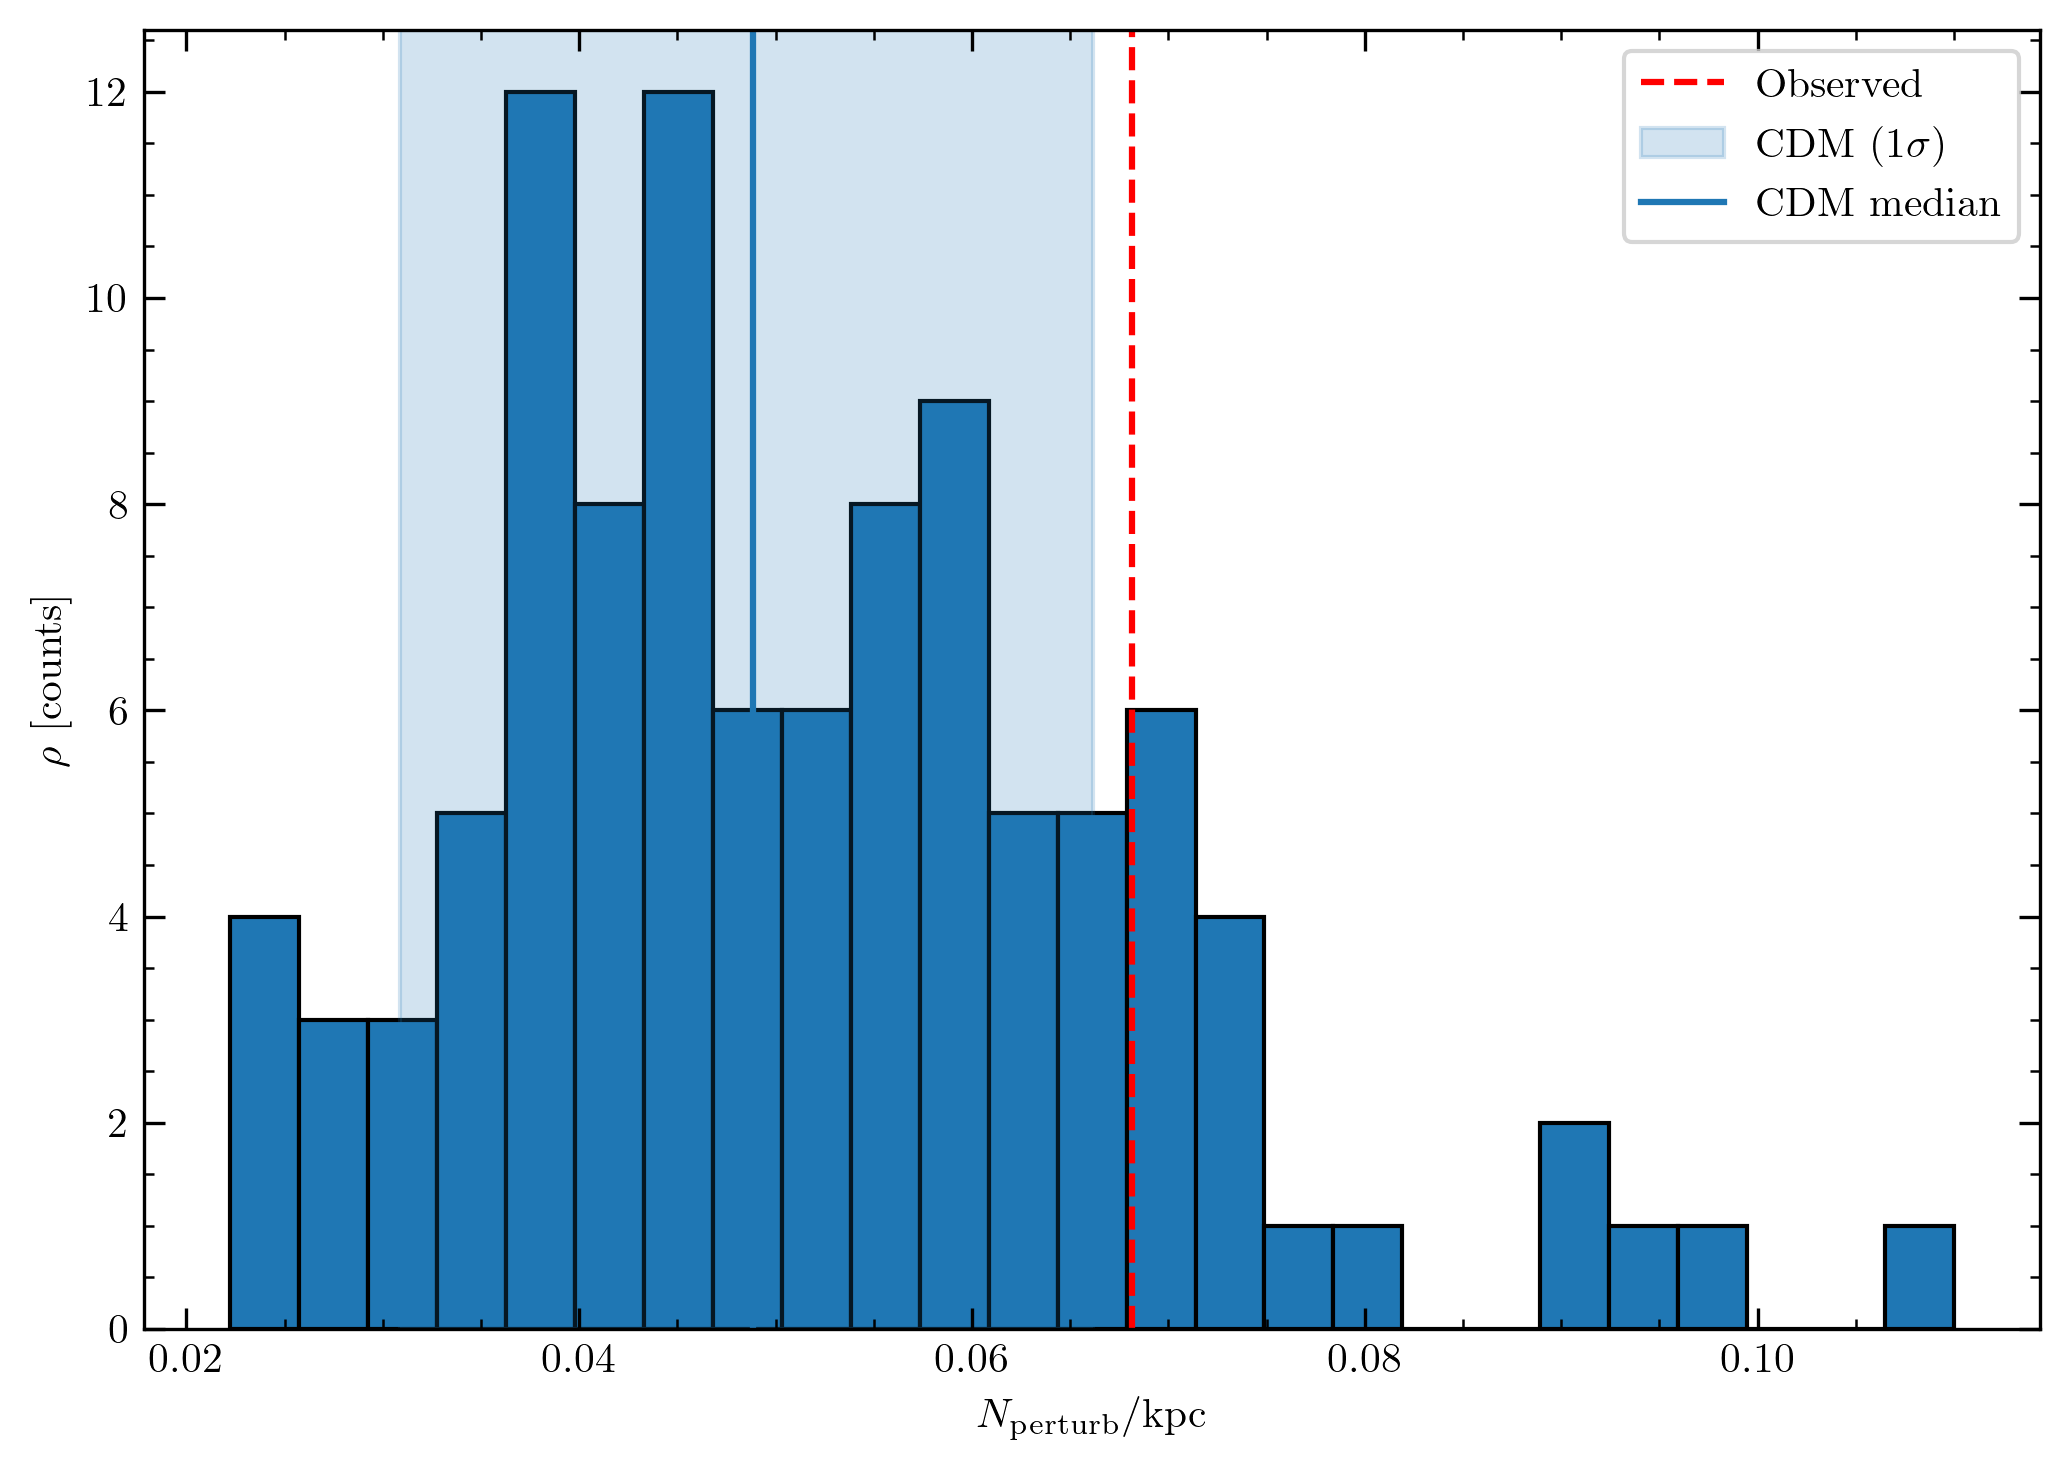

In [21]:
pop = population_perturbation_rates()

med = np.median(pop["per_kpc"])
std = np.std(pop["per_kpc"])
poneminus = np.max(pop["per_kpc"][pop["per_kpc"] < med - std])
poneplus = np.min(pop["per_kpc"][pop["per_kpc"] > med + std])
print("CDM N_perturb/kpc @ GD-1 (D=8 kpc, T=12 Gyr):")
print(f"  median = {med:.3g}")
print(f"  1-sigma range = {poneminus:.3g} – {poneplus:.3g}")
print(
    f"  full range across {len(pop['per_kpc'])} hosts:"
    f" {pop['per_kpc'].min():.3g} – {pop['per_kpc'].max():.3g}"
)

plt.figure(figsize=(7, 5))
plt.hist(pop["per_kpc"], bins=25, edgecolor="k")
plt.axvline(9 / 132.1, color="red", ls="--", label="Observed")
plt.axvspan(poneminus, poneplus, color="C0", alpha=0.2, label=r"CDM (1$\sigma$)")
plt.axvline(med, color="C0", label="CDM median")
plt.xlabel(r"$N_{\rm perturb}/{\rm kpc}$")
plt.ylabel(r"$\rho$ [counts]")
plt.legend()
plt.tight_layout()
plt.savefig("./plots/stream_perturbation_rate_distribution_cdm.png", dpi=300)
plt.show()